# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [107]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


Python executable: /Users/nick/College Schoolwork Local/SP26/EE446/tinyml-arduino/bin/python
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [108]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 3. Load the Data

In [109]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32
    # 5. Convert labels to zero-based class indices by subtracting 1

    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"))
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt")).astype(int) - 1

    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"))
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt")).astype(int) - 1

    return X_train, y_train, X_test, y_test
    raise NotImplementedError("Complete the data-loading function.")

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# Define num_features and num_classes.
# Print the train/test shapes and the number of features/classes.

num_features = X_train.shape[1]
num_classes = len(np.unique(y_train))
print("number of features:", num_features)
print("number of classes:", num_classes)


number of features: 561
number of classes: 6


## 4. Quick Inspection

In [110]:
# Create a small summary table showing:
# - class index,
# - class name, and
# - number of training samples in each class.

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Number of input features:", num_features)
print("Number of classes:", num_classes)
label_counts = pd.Series(y_train).value_counts().sort_index()
summary_df = pd.DataFrame({
    "Class Index": range(num_classes),
    "Class Name": class_names,
    "Training Samples": label_counts.values
})
summary_df


X_train shape: (7352, 561)
X_test shape : (2947, 561)
Number of input features: 561
Number of classes: 6


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [111]:
def build_baseline_model(input_dim, num_classes):
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(256, activation="relu", name="Dense1")(inputs)
    x = layers.Dense(128, activation="relu", name="Dense2")(x)
    x = layers.Dense(64, activation="relu", name="Dense3")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="classifier")(x)
    return keras.Model(inputs,outputs, name="baseline_model")

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"],
)
baseline_model.summary()


Model: "baseline_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_12 (InputLayer)       [(None, 561)]             0         
                                                                 
 Dense1 (Dense)              (None, 256)               143872    
                                                                 
 Dense2 (Dense)              (None, 128)               32896     
                                                                 
 Dense3 (Dense)              (None, 64)                8256      
                                                                 
 classifier (Dense)          (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [112]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

history_baseline = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    verbose=1,
    callbacks=callbacks,
)


Epoch 1/40
92/92 [==============================] - 0s 1ms/step - loss: 0.4880 - accuracy: 0.8073 - val_loss: 0.2027 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 1ms/step - loss: 0.1655 - accuracy: 0.9361 - val_loss: 0.1358 - val_accuracy: 0.9368
Epoch 3/40
92/92 [==============================] - 0s 1ms/step - loss: 0.1252 - accuracy: 0.9505 - val_loss: 0.1966 - val_accuracy: 0.9273
Epoch 4/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0981 - accuracy: 0.9595 - val_loss: 0.1258 - val_accuracy: 0.9443
Epoch 5/40
92/92 [==============================] - 0s 993us/step - loss: 0.0756 - accuracy: 0.9719 - val_loss: 0.1641 - val_accuracy: 0.9266
Epoch 6/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0692 - accuracy: 0.9755 - val_loss: 0.2387 - val_accuracy: 0.9252
Epoch 7/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0602 - accuracy: 0.9767 - val_loss: 0.1413 - val_accuracy: 0.9429
Epoch 8/40
92/92 [

### Training Curves

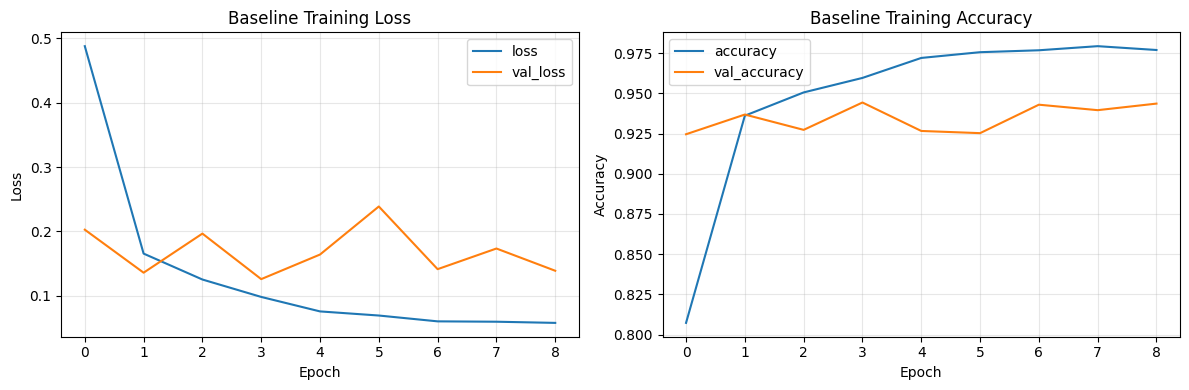

In [113]:
# Plot:
# 1. training accuracy vs validation accuracy
# 2. training loss vs validation loss

history_df = pd.DataFrame(history_baseline.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

history_df[["loss", "val_loss"]].plot(ax=axes[0], title="Baseline Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1], title="Baseline Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Evaluate the Baseline Keras Model

93/93 [==============================] - 0s 412us/step
Accuracy 0.9290804207668816
Classification Report
                    precision    recall  f1-score   support

           WALKING       0.90      0.98      0.94       496
  WALKING_UPSTAIRS       0.95      0.88      0.92       471
WALKING_DOWNSTAIRS       0.94      0.92      0.93       420
           SITTING       0.93      0.87      0.90       491
          STANDING       0.86      0.94      0.90       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



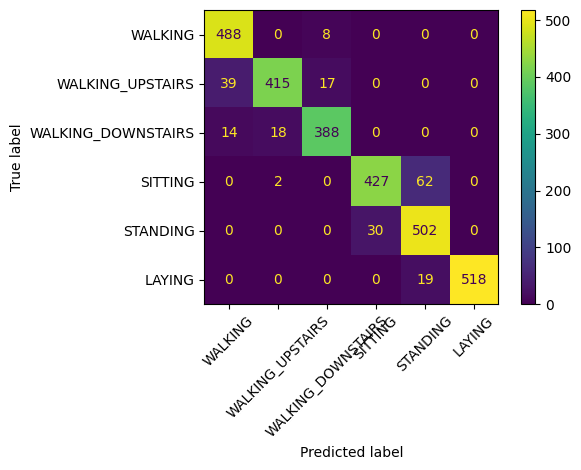

In [114]:
# TODO:
# 1. Predict class probabilities on X_test
# 2. Convert probabilities to class labels using argmax
# 3. Compute the test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

X_test_probabilities = baseline_model.predict(X_test)
X_test_predictions = np.argmax(X_test_probabilities, axis=1)
accuracy = accuracy_score(y_test, X_test_predictions)
print("Accuracy",accuracy)
print("Classification Report")
print(classification_report(y_test, X_test_predictions, target_names=class_names))

cm = confusion_matrix(y_test, X_test_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.show()


# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [115]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # Quantize the input only when the TFLite input tensor expects int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        if input_details["dtype"]==np.int8:
            if input_scale == 0:
                raise ValueError("INT8 model has invalid input quantization scale 0.")
            x = np.round(x/input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"]==np.uint8:
            if input_scale == 0:
                raise ValueError("UINT8 model has invalid input quantization scale 0.")
            x = np.round(x/input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # Dequantize the output only when the output tensor is int8 or uint8.

        if output_details["dtype"] in (np.int8, np.uint8) and output_scale != 0:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model, optimizations):
    # TODO:
    # Create a TFLiteConverter from the Keras model and return the converted FP32 model bytes.
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = optimizations
    return converter.convert()
    


## 8. Convert the Baseline Model to TensorFlow Lite

In [116]:
# Convert the baseline model to FP32 TensorFlow Lite.
# Save the .tflite file, compute its size in KB, and evaluate it on X_test.

OUTPUT_DIR = Path("quantization_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
tflite_fp32 = convert_to_tflite_fp32(baseline_model, [])
size_fp32 = save_binary_model(tflite_fp32, OUTPUT_DIR/"pruning_notebook_baseline_fp32.tflite")
accuracy_fp32, fp32_pred = evaluate_tflite_model(tflite_fp32, X_test, y_test)


INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpo1r2w24a/assets


INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpo1r2w24a/assets
2026-04-18 19:39:59.548830: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-18 19:39:59.548842: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-18 19:39:59.548952: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpo1r2w24a
2026-04-18 19:39:59.549400: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-18 19:39:59.549404: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpo1r2w24a
2026-04-18 19:39:59.550567: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-18 19:39:59.570904: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [117]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# Compute steps_per_epoch using 80% of the training set and the selected batch size.
# Define pruning_params using PolynomialDecay with:
# - initial_sparsity=0.20
# - final_sparsity=0.85
# - begin_step=0
# - end_step=steps_per_epoch * pruning_epochs

steps_per_epoch = int(np.ceil(0.8*len(X_train)/batch_size))
pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.2,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs
        )
    }

# Create the pruned model by wrapping a fresh baseline DNN with prune_low_magnitude.
# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.

pruned_model = prune_low_magnitude(build_baseline_model(num_features, num_classes), **pruning_params)
pruned_model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"],
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# Train the pruned model using:
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks

history_pruned = pruned_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    verbose=1,
    callbacks=pruning_callbacks,
)


Epoch 1/12
92/92 [==============================] - 1s 2ms/step - loss: 0.4751 - accuracy: 0.8065 - val_loss: 0.2229 - val_accuracy: 0.9225
Epoch 2/12
92/92 [==============================] - 0s 1ms/step - loss: 0.1671 - accuracy: 0.9374 - val_loss: 0.1593 - val_accuracy: 0.9300
Epoch 3/12
92/92 [==============================] - 0s 1ms/step - loss: 0.1261 - accuracy: 0.9514 - val_loss: 0.2292 - val_accuracy: 0.9259
Epoch 4/12
92/92 [==============================] - 0s 1ms/step - loss: 0.0888 - accuracy: 0.9696 - val_loss: 0.1739 - val_accuracy: 0.9334
Epoch 5/12
92/92 [==============================] - 0s 1ms/step - loss: 0.1374 - accuracy: 0.9463 - val_loss: 0.1431 - val_accuracy: 0.9395
Epoch 6/12
92/92 [==============================] - 0s 1ms/step - loss: 0.1286 - accuracy: 0.9546 - val_loss: 0.1580 - val_accuracy: 0.9395
Epoch 7/12
92/92 [==============================] - 0s 1ms/step - loss: 0.3376 - accuracy: 0.9209 - val_loss: 0.1784 - val_accuracy: 0.9334
Epoch 8/12
92/92 [==

## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [118]:
# 1. Convert the pruned model WITH the pruning wrappers still attached to FP32 TensorFlow Lite.
# 2. Save the model and evaluate it on X_test.
# 3. Strip the pruning wrappers using strip_pruning(...).
# 4. Convert the stripped model with tf.lite.Optimize.EXPERIMENTAL_SPARSITY.
# 5. Save the stripped sparse model and evaluate it on X_test.

tflite_fp32_pruned_wrapped = convert_to_tflite_fp32(pruned_model, [])
size_fp32_pruned_wrapped = save_binary_model(tflite_fp32_pruned_wrapped, OUTPUT_DIR/"pruning_notebook_pruned_wrapped_fp32.tflite")
accuracy_fp32_pruned_wrapped, fp32_pruned_wrapped_pred = evaluate_tflite_model(tflite_fp32_pruned_wrapped, X_test, y_test)

stripped_model = strip_pruning(pruned_model)
tflite_fp32_stripped_sparse = convert_to_tflite_fp32(stripped_model, [tf.lite.Optimize.EXPERIMENTAL_SPARSITY])
size_fp32_stripped_sparse = save_binary_model(tflite_fp32_stripped_sparse, OUTPUT_DIR/"pruning_notebook_stripped_sparse_fp32.tflite")
accuracy_fp32_stripped_sparse, fp32_stripped_sparse_pred = evaluate_tflite_model(tflite_fp32_stripped_sparse, X_test, y_test)


INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpqtc5g414/assets


INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpqtc5g414/assets
2026-04-18 19:40:01.834486: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-18 19:40:01.834497: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-18 19:40:01.834593: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpqtc5g414
2026-04-18 19:40:01.835860: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-18 19:40:01.835865: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpqtc5g414
2026-04-18 19:40:01.839363: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-18 19:40:01.867575: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpcdshl6_l/assets


INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpcdshl6_l/assets
2026-04-18 19:40:02.539796: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-18 19:40:02.539810: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-18 19:40:02.539901: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpcdshl6_l
2026-04-18 19:40:02.540229: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-18 19:40:02.540233: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpcdshl6_l
2026-04-18 19:40:02.541018: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-18 19:40:02.549015: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

## 11. Part I Comparison: Accuracy and Model Size

In [119]:
# Create a comparison DataFrame for Part I with the columns:
# Model, Format, Test Accuracy, Model Size (KB)

# Include:
# - baseline FP32 TFLite
# - pruned FP32 TFLite with mask
# - stripped sparse FP32 TFLite

df_data = {
    "Model": ["baseline FP32 TFLite", "Pruned FP32 TFLite with mask", "Stripped sparse FP32 TFLite"],
    "Format": ["FP32 TFLite"]*3,
    "Test Accuracy": [accuracy_fp32, accuracy_fp32_pruned_wrapped, accuracy_fp32_stripped_sparse],
    "Model Size (KB)": [size_fp32, size_fp32_pruned_wrapped, size_fp32_stripped_sparse]
}
df = pd.DataFrame(df_data)
print(df)


                          Model       Format  Test Accuracy  Model Size (KB)
0          baseline FP32 TFLite  FP32 TFLite       0.929080       726.816406
1  Pruned FP32 TFLite with mask  FP32 TFLite       0.922294      1454.292969
2   Stripped sparse FP32 TFLite  FP32 TFLite       0.922294       338.937500


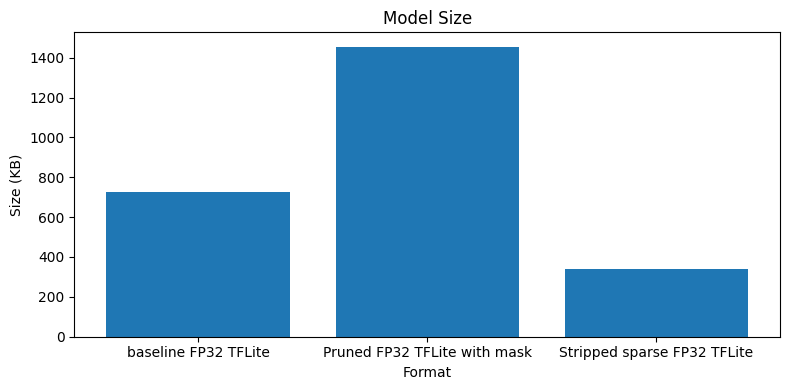

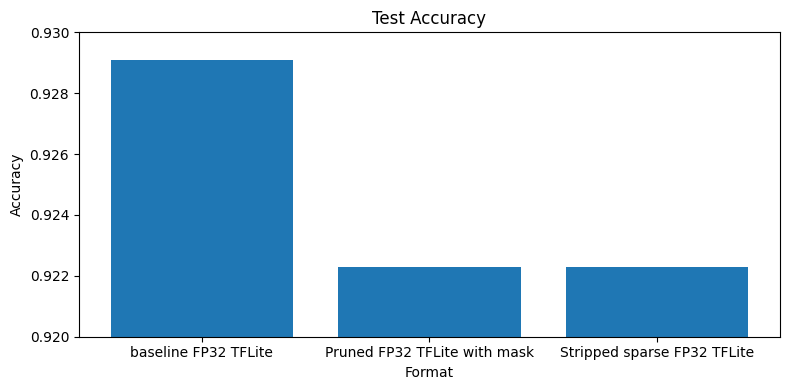

In [120]:
# Plot:
# 1. a bar chart of the Part I model sizes
# 2. a bar chart of the Part I test accuracies

# Model size plot
plt.figure(figsize=(8,4))
plt.bar(df_data["Model"], df_data["Model Size (KB)"])
plt.title("Model Size")
plt.xlabel("Format")
plt.ylabel("Size (KB)")
plt.tight_layout()
plt.show()

# Test accuracy plot
plt.figure(figsize=(8,4))
plt.bar(df_data["Model"], df_data["Test Accuracy"])
plt.title("Test Accuracy")
plt.xlabel("Format")
plt.ylabel("Accuracy")
plt.ylim(0.92, 0.93)

plt.tight_layout()
plt.show()


### Confusion Matrix for the Stripped Sparse Model

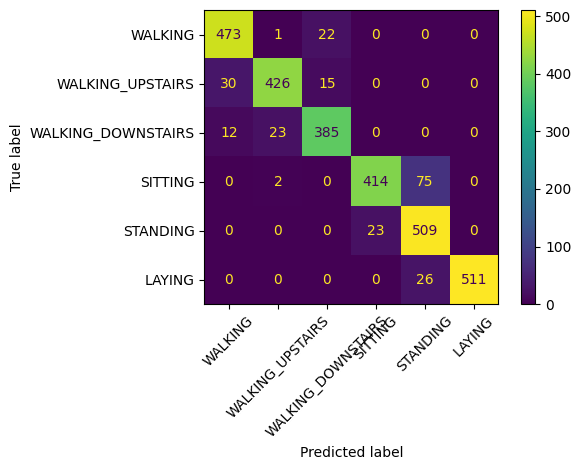

                    precision    recall  f1-score   support

           WALKING       0.92      0.95      0.94       496
  WALKING_UPSTAIRS       0.94      0.90      0.92       471
WALKING_DOWNSTAIRS       0.91      0.92      0.91       420
           SITTING       0.95      0.84      0.89       491
          STANDING       0.83      0.96      0.89       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



In [121]:
# Plot the confusion matrix for the stripped sparse TFLite model.
# Print the classification report for the stripped sparse TFLite model.

cm = confusion_matrix(y_test, fp32_stripped_sparse_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.show()

print(classification_report(y_test, fp32_stripped_sparse_pred, target_names=class_names))


# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [122]:
# Part II: combine pruning and float16 quantization.
#
# 1. Convert the pruned model with mask using:
#    - optimizations = [tf.lite.Optimize.DEFAULT]
#    - supported_types = [tf.float16]
# 2. Save and evaluate the float16 model with mask.
# 3. Convert the stripped sparse model using:
#    - optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
#    - supported_types = [tf.float16]
# 4. Save and evaluate the stripped sparse + float16 model.

def convert_to_tflite_float16(model, optimizations):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)    
    converter.optimizations = optimizations
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

tflite_float16_pruned_wrapped = convert_to_tflite_float16(pruned_model, [tf.lite.Optimize.DEFAULT])
size_float16_pruned_wrapped = save_binary_model(tflite_float16_pruned_wrapped, OUTPUT_DIR/"pruning_notebook_pruned_wrapped_fp16.tflite")
accuracy_fp16_pruned_wrapped, fp16_pruned_wrapped_pred = evaluate_tflite_model(tflite_float16_pruned_wrapped, X_test, y_test)

tflite_float16_stripped_sparse = convert_to_tflite_float16(stripped_model, [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY])
size_float16_stripped_sparse = save_binary_model(tflite_float16_stripped_sparse, OUTPUT_DIR/"pruning_notebook_stripped_sparse_fp16.tflite")
accuracy_float16_stripped_sparse, float16_stripped_sparse_pred = evaluate_tflite_model(tflite_float16_stripped_sparse, X_test, y_test)


INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpuk0mzb03/assets


INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpuk0mzb03/assets
2026-04-18 19:40:03.567436: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-18 19:40:03.567448: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-18 19:40:03.567545: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpuk0mzb03
2026-04-18 19:40:03.568738: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-18 19:40:03.568742: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpuk0mzb03
2026-04-18 19:40:03.571945: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-18 19:40:03.599991: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpj61024mr/assets


INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpj61024mr/assets
2026-04-18 19:40:04.098363: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-18 19:40:04.098376: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-18 19:40:04.098479: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpj61024mr
2026-04-18 19:40:04.098767: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-18 19:40:04.098772: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpj61024mr
2026-04-18 19:40:04.099443: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-18 19:40:04.107648: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

## 12. Part II Comparison: Accuracy and Model Size

In [123]:
# Create a Part II comparison DataFrame with the columns:
# Model, Format, Test Accuracy, Model Size (KB)
#
# Include:
# - pruned FP32 with mask
# - stripped sparse FP32
# - pruned float16 with mask
# - stripped sparse float16

df_data = {
    "Model": ["Pruned FP32 with mask", "Stripped sparse FP32", "Pruned float16 with mask", "Stripped sparse float16"],
    "Format": ["FP32 TFLite","FP32 TFLite","float16 TFLite","float16 TFLite"],
    "Test Accuracy": [accuracy_fp32_pruned_wrapped, accuracy_fp32_stripped_sparse, accuracy_fp16_pruned_wrapped, accuracy_fp16_stripped_sparse],
    "Model Size (KB)": [size_fp32_pruned_wrapped, size_fp32_stripped_sparse, size_float16_pruned_wrapped, size_float16_stripped_sparse]
}
df = pd.DataFrame(df_data)
print(df)


                      Model          Format  Test Accuracy  Model Size (KB)
0     Pruned FP32 with mask     FP32 TFLite       0.922294      1454.292969
1      Stripped sparse FP32     FP32 TFLite       0.922294       338.937500
2  Pruned float16 with mask  float16 TFLite       0.922294       732.710938
3   Stripped sparse float16  float16 TFLite       0.922294       223.773438


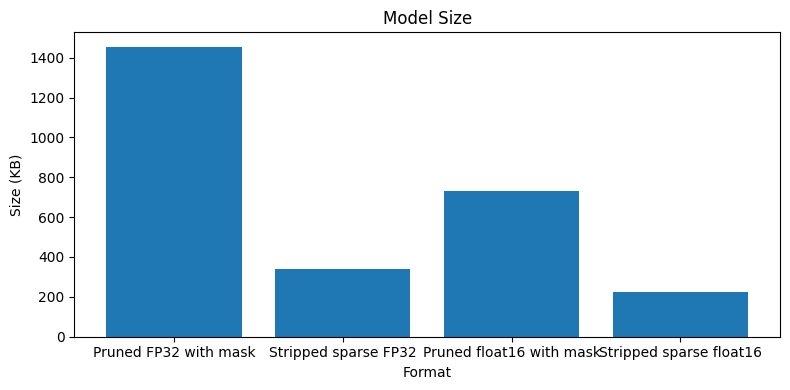

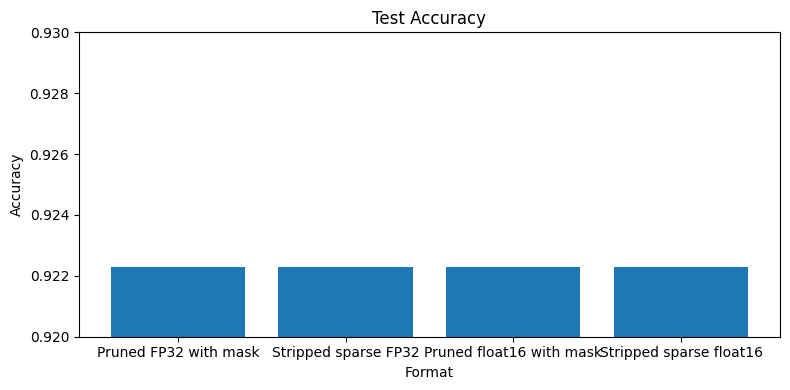

In [124]:
# TODO:
# Plot:
# 1. a bar chart of Part II model sizes
# 2. a bar chart of Part II test accuracies

# Model size plot
plt.figure(figsize=(8,4))
plt.bar(df_data["Model"], df_data["Model Size (KB)"])
plt.title("Model Size")
plt.xlabel("Format")
plt.ylabel("Size (KB)")
plt.tight_layout()
plt.show()

# Test accuracy plot
plt.figure(figsize=(8,4))
plt.bar(df_data["Model"], df_data["Test Accuracy"])
plt.title("Test Accuracy")
plt.xlabel("Format")
plt.ylabel("Accuracy")
plt.ylim(0.92, 0.93)

plt.tight_layout()
plt.show()


### Confusion Matrix for the Stripped Sparse + Float16 Model

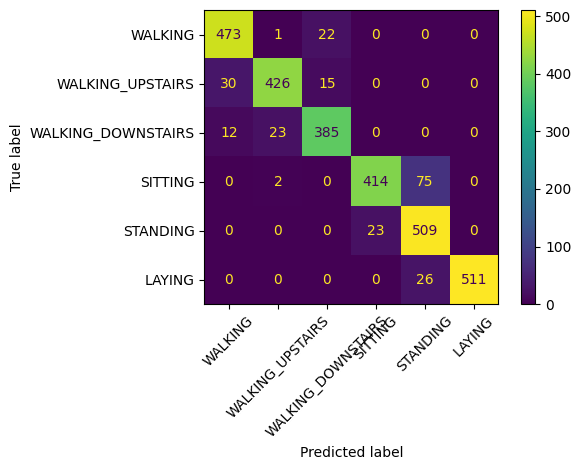

                    precision    recall  f1-score   support

           WALKING       0.92      0.95      0.94       496
  WALKING_UPSTAIRS       0.94      0.90      0.92       471
WALKING_DOWNSTAIRS       0.91      0.92      0.91       420
           SITTING       0.95      0.84      0.89       491
          STANDING       0.83      0.96      0.89       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



In [125]:
# Plot the confusion matrix for the stripped sparse + float16 TFLite model.
# Print the classification report for the stripped sparse + float16 TFLite model.

cm = confusion_matrix(y_test, float16_stripped_sparse_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.show()

print(classification_report(y_test, float16_stripped_sparse_pred, target_names=class_names))


## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached? Pruning doesn't reduce the filesize because the mask is still attached to the model, making it larger than needed.
2. Why does `strip_pruning(...)` matter before export? strip_pruning matters before exporting because it removes the wrappers and leave only the sparse weights.
3. Which model had the smallest file size in this notebook? The stripped sparse float16 model is the smallest.
4. Did float16 quantization noticeably change the test accuracy? float16 quantization didn't change the test accuracy. The amount of precision doesn't change much from float32 to float16
5. If you were deploying this model on a resource-constrained device, which version would you choose and why? I would choose the stripped sparse float16 model because it uses the smallest amount of resources while still maintaining a very similar amount of accuracy as larger-sized models.


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
